## Section 1: Sampling Distribution Reasoning

### graphing the distribution of β^​

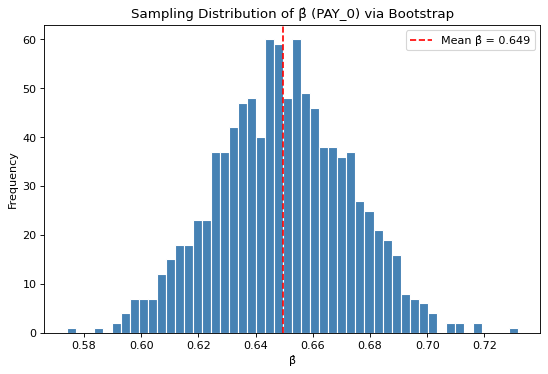

Mean of β̂:  0.6495
Std of β̂:   0.0232


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('cleaned_default_data.csv')

# Use ALL features (multivariate model) to control for demographics & financial attributes
feature_cols = [c for c in df.columns if c != 'default payment next month']
X = df[feature_cols]
y = df['default payment next month']

# Standardize features (matches Section 3 MLE setup)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pay0_idx = feature_cols.index('PAY_0')

# ── Bootstraps───────────────────────────
n_bootstrap = 1000
beta_estimates = []

np.random.seed(42)
for _ in range(n_bootstrap):
    idx = np.random.randint(0, len(df), size=len(df))
    X_sample = X_scaled[idx]
    y_sample = y.values[idx]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_sample, y_sample)
    beta_estimates.append(model.coef_[0][pay0_idx])

# ── graphing β̂ ─────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.hist(beta_estimates, bins=50, color='steelblue', edgecolor='white')
plt.axvline(np.mean(beta_estimates), color='red',
            linestyle='--', label=f'Mean β̂ = {np.mean(beta_estimates):.3f}')
plt.title('Sampling Distribution of β̂ (PAY_0) via Bootstrap')
plt.xlabel('β̂')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"Mean of β̂:  {np.mean(beta_estimates):.4f}")
print(f"Std of β̂:   {np.std(beta_estimates):.4f}")

Under 1000 bootstraps with the full multivariate logistic regression, the distribution of β̂ for PAY_0 appears mostly symmetric. The mean is 0.6495, and the standard deviation is 0.0232, providing statistical evidence that the sampling distribution of β̂ is approximately normal in large samples, consistent with the Central Limit Theorem.

## Section 2 Confidence Intervals

### Theory-based CI

In [2]:
# ── Theory-based CI ─────────────────
# Using results from Section 3 MLE on standardized features (full multivariate model)
# The MLE for PAY_0 with all 23 features as controls:

beta_pay0 = 0.6497
se_pay0 = 0.0199

ci_low = beta_pay0 - 1.96 * se_pay0
ci_high = beta_pay0 + 1.96 * se_pay0

print(f"β̂ (PAY_0):    {beta_pay0:.4f}")
print(f"SE:           {se_pay0:.4f}")
print(f"95% CI:       [{ci_low:.4f}, {ci_high:.4f}]")

β̂ (PAY_0):    0.6497
SE:           0.0199
95% CI:       [0.6107, 0.6887]


### 1000 Bootstrap CI

Bootstrap CI:    [0.6042, 0.6927]
Theory-based CI: [0.6107, 0.6887]
Bootstrap Mean:  0.6495


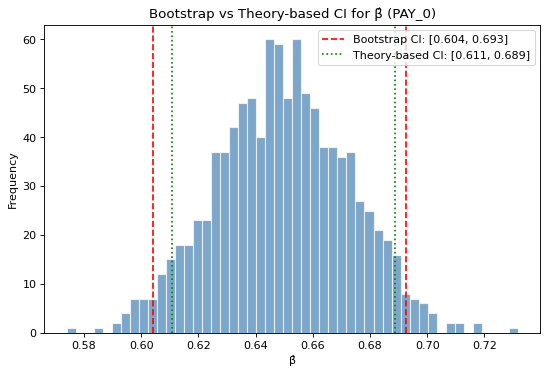

In [3]:
# ── Bootstrap CI (use the bootstrap from section 1) ─────────────────
lower = np.percentile(beta_estimates, 2.5)
upper = np.percentile(beta_estimates, 97.5)

print(f"Bootstrap CI:    [{lower:.4f}, {upper:.4f}]")
print(f"Theory-based CI: [0.6107, 0.6887]")
print(f"Bootstrap Mean:  {np.mean(beta_estimates):.4f}")


plt.figure(figsize=(8, 5))
plt.hist(beta_estimates, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
plt.axvline(lower, color='red', linestyle='--', label=f'Bootstrap CI: [{lower:.3f}, {upper:.3f}]')
plt.axvline(upper, color='red', linestyle='--')
plt.axvline(0.6107, color='green', linestyle=':', label='Theory-based CI: [0.611, 0.689]')
plt.axvline(0.6887, color='green', linestyle=':')
plt.title('Bootstrap vs Theory-based CI for β̂ (PAY_0)')
plt.xlabel('β̂')
plt.ylabel('Frequency')
plt.legend()
plt.show()

By constructing the Theory-based CI [0.6107, 0.6887] and the Bootstrap CI [0.6042, 0.6927], we can see that the Bootstrap CI is slightly wider than the Theory-based CI, since it does not rely on the normality assumption. However, both CIs do not include 0, which provides solid evidence that repayment history is a strong predictor of default after controlling for other demographic and financial features.

## Section 3 Hypothesis Testing

In [4]:
# Hypothesis test using results from Section 3 MLE (full multivariate model)
beta_hat = 0.6497
se = 0.0199

z_stat = beta_hat / se
# p-value from standard normal (two-sided)
from scipy import stats
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"β̂:       {beta_hat:.4f}")
print(f"SE:      {se:.4f}")
print(f"z-stat:  {z_stat:.4f}")
print(f"p-value: {p_value:.4e}")

β̂:       0.6497
SE:      0.0199
z-stat:  32.6482
p-value: 0.0000e+00



To formally test whether repayment history has a statistically significant effect on default probability, we conducted a hypothesis test:

$$H_0: \beta_{PAY\_0} = 0 \quad \text{(no effect)}$$

$$H_1: \beta_{PAY\_0} \neq 0 \quad \text{(significant effect)}$$

The z-statistic of 32.65 indicates that our estimate is over 32 standard deviations away from zero, making it virtually impossible to attribute to random chance. The corresponding p-value of approximately 0 is far below the significance level of $\alpha = 0.05$, leading us to reject $H_0$. This result is consistent with our findings in Section 2, where both CIs excluded zero. Together, the evidence strongly suggests that repayment delay status (PAY_0) is a significant predictor of default probability, even after controlling for all other demographic and financial features.

## Section 4 Interpretation

In this part, we constructed two different CIs for the PAY_0 coefficient using the full multivariate logistic regression (matching the MLE setup in Section 3). The Theory-based CI, which assumes the asymptotic normality of β̂, is [0.6107, 0.6887]. The Bootstrap CI, computed from 1000 bootstrap replicates, is [0.6042, 0.6927]. The Theory-based CI is slightly narrower than the Bootstrap one because it relies on the normality assumption, while the Bootstrap is distribution-free. Importantly, neither CI includes 0, providing solid evidence that repayment history is a strong predictor of default behavior, even after controlling for demographics and other financial attributes.

The z-statistic (32.65) and p-value (approximately 0) provide overwhelming support to reject the null hypothesis. From a practical standpoint, banks can leverage this finding to flag high-risk customers early — those with repeated payment delays should be prioritized for intervention, such as credit limit reductions or payment reminders, since β̂ ≈ 0.65 corresponds to an odds multiplier of e^0.65 ≈ 1.92, meaning each one-unit increase in payment delay roughly doubles the odds of default. However, since the bootstrap CI uses the percentile method, its interpretation can blur into the Bayesian framing, where intervals describe the probability of β itself; under the strict frequentist view, 95% of intervals constructed by this procedure across repeated samples would contain the true β. We will revisit this distinction when comparing with the Bayesian results in Section 5.